# 01 – Data exploration
Goal: understand the London Inside Airbnb listings data before building a model to predict nightly price.

In [1]:
    import pandas as pd

    df = pd.read_csv("../data/raw/listings.csv.gz")
    print(df.shape)
    print(df.columns.tolist())



(24876, 90)
['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_profile_id', 'host_profile_url', 'host_name', 'host_since', 'hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_total_price', 'price_quote_price_per_night', 'price_quote_raw', 

In [2]:
print("Data type:", df["price"].dtype)
print("Missing prices:", df["price"].isna().sum())
df["price"].head(10)

Data type: str
Missing prices: 2240


0       $90.67
1      $108.98
2      $122.00
3    $1,096.00
4      $119.83
5       $80.00
6      $109.00
7       $95.00
8      $221.00
9       $95.33
Name: price, dtype: str

In [3]:
df["price_num"] = (
    df["price"]
    .str.replace(r"[£$,]", "", regex=True)
    .astype(float)
)
df["price_num"].describe().round(1)

count    22636.0
mean       189.8
std        379.0
min          3.7
25%         92.0
50%        136.0
75%        200.0
max      16077.5
Name: price_num, dtype: float64

In [4]:
key_cols = [
    "price", "neighbourhood_cleansed", "room_type", "accommodates",
    "bedrooms", "bathrooms", "beds", "latitude", "longitude",
    "number_of_reviews", "review_scores_rating",
]
df[key_cols].isna().mean().sort_values(ascending=False).round(3)

bedrooms                  0.179
bathrooms                 0.149
review_scores_rating      0.125
beds                      0.101
price                     0.090
neighbourhood_cleansed    0.000
room_type                 0.000
accommodates              0.000
latitude                  0.000
longitude                 0.000
number_of_reviews         0.000
dtype: float64

## Initial findings
- 24,876 listings; 2,240 (9%) have no price and are removed, as the model needs a known price to learn from.
- Prices are heavily right-skewed: median £136, mean £190, maximum £16,077. 75% of listings cost £200 or less.
- Bedrooms (18%), bathrooms (15%) and beds (10%) have missing values, to be filled in during cleaning.
- Location, room type and capacity have no missing values.

In [5]:
df = df.dropna(subset=["price_num"]).copy()
print(df.shape)

(22636, 91)


In [6]:
df["price_num"].quantile([0.001, 0.01, 0.05, 0.95, 0.99, 0.999]).round(1)

0.001      16.8
0.010      29.0
0.050      46.8
0.950     442.1
0.990    1027.1
0.999    5006.1
Name: price_num, dtype: float64

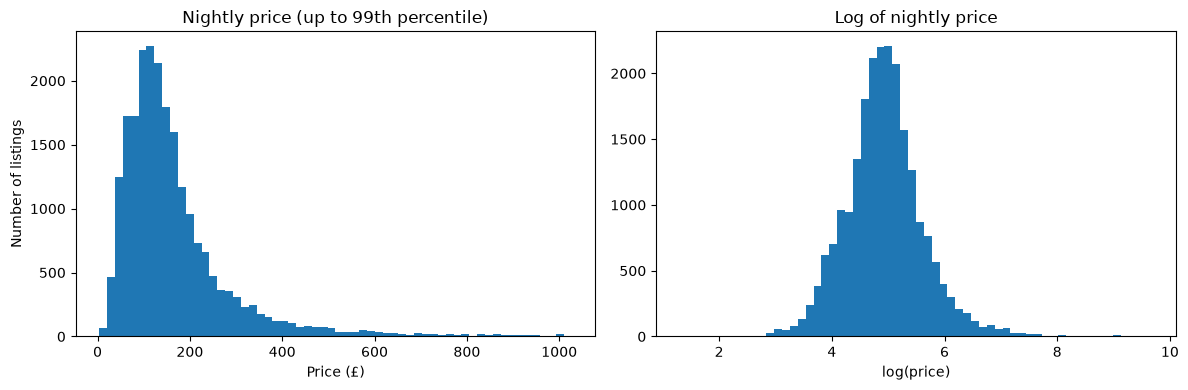

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt

os.makedirs("../reports/figures", exist_ok=True)

cap = df["price_num"].quantile(0.99)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df.loc[df["price_num"] <= cap, "price_num"], bins=60)
axes[0].set_title("Nightly price (up to 99th percentile)")
axes[0].set_xlabel("Price (£)")
axes[0].set_ylabel("Number of listings")

axes[1].hist(np.log(df["price_num"]), bins=60)
axes[1].set_title("Log of nightly price")
axes[1].set_xlabel("log(price)")

plt.tight_layout()
plt.savefig("../reports/figures/price_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
pd.crosstab(
    df["review_scores_rating"].isna(),
    df["number_of_reviews"] == 0,
    rownames=["review score missing"],
    colnames=["zero reviews"],
)

zero reviews,False,True
review score missing,,
False,19953,0
True,0,2683
